# Employee Performance Analysis

## Importing  Libraries

In [1]:
# ===============================
# 1. Ignore Warnings
# ===============================
import warnings
warnings.filterwarnings('ignore')

# ===============================
# 2. Data Handling & Computation
# ===============================
import numpy as np
import pandas as pd

# ===============================
# 3. Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use('default')
sns.set_theme(style="whitegrid")

# ===============================
# 4. Data Preprocessing
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ===============================
# 5. Regression Models (Price Prediction)
# ===============================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ===============================
# 6. Model Evaluation Metrics
# ===============================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ===============================
# 7. Model Tuning
# ===============================
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV




## Loading the Dataset

In [2]:
df = pd.read_excel('INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xlsx')

In [3]:
df

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3


## Basic Checks

In [4]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [5]:
df.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


In [6]:
df.shape

(1200, 28)

In [7]:
print("Column names:")
print(df.columns.tolist())


Column names:
['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition', 'PerformanceRating']


In [8]:
df.dtypes


EmpNumber                       object
Age                              int64
Gender                          object
EducationBackground             object
MaritalStatus                   object
EmpDepartment                   object
EmpJobRole                      object
BusinessTravelFrequency         object
DistanceFromHome                 int64
EmpEducationLevel                int64
EmpEnvironmentSatisfaction       int64
EmpHourlyRate                    int64
EmpJobInvolvement                int64
EmpJobLevel                      int64
EmpJobSatisfaction               int64
NumCompaniesWorked               int64
OverTime                        object
EmpLastSalaryHikePercent         int64
EmpRelationshipSatisfaction      int64
TotalWorkExperienceInYears       int64
TrainingTimesLastYear            int64
EmpWorkLifeBalance               int64
ExperienceYearsAtThisCompany     int64
ExperienceYearsInCurrentRole     int64
YearsSinceLastPromotion          int64
YearsWithCurrManager     

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

## Checking for Missing values

In [10]:
# Count missing values column-wise
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

# Total missing values in dataset
print("Total missing values:", df.isnull().sum().sum())


Missing values per column:
EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64
Total mi

## 📊 Data Structure Report (df.info())

- The dataset contains **1200 rows and 28 columns**, representing employee-level information.
- There are **no missing values**; all columns have 1200 non-null entries.
- The dataset includes **19 numerical (int64) features** and **9 categorical (object) features**.
- The target variable is **PerformanceRating (int64)**, indicating this is likely a classification problem.
- `EmpNumber` is an identifier column and should not be used for modeling.


In [11]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [12]:
df.describe()


,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


## 📊 Numerical Summary Report 

- The workforce has an average age of **36.9 years**, with ages ranging from **18 to 60 years**, indicating a balanced mix of early and mid-career employees.
- Employees have an average of **11.3 years of total work experience** and **7.1 years at the company**, suggesting moderate workforce stability.
- Satisfaction-related metrics (Environment, Job, Relationship, Work-Life Balance) have mean values around **2.7–2.8 (on a 1–4 scale)**, indicating moderate overall satisfaction levels.
- The average **PerformanceRating is 2.95 (on a 2–4 scale)**, with most employees concentrated around rating 3.
- Salary hike percentage averages **15.2%**, with variation between **11% and 25%**, showing differentiated performance-based increments.


In [13]:
df.describe(include='object')


,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E1001000,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


## 📊 Categorical Summary Report

- The dataset contains 9 categorical variables, each with 1200 non-null values, confirming no missing categorical data.
- Gender distribution shows a majority of **Male employees (725 out of 1200)**.
- The most common education background is **Life Sciences (492 employees)**, and the majority of employees are **Married (548)**.
- The largest department is **Sales (373 employees)**, with **Sales Executive (270 employees)** being the most frequent job role.
- Most employees **travel rarely (846)**, do **not work overtime (847)**, and the majority have **not left the company (Attrition = No, 1022 employees)**.


In [14]:
df['PerformanceRating'].value_counts()


PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())



Column: EmpNumber
['E1001000' 'E1001006' 'E1001007' ... 'E100994' 'E100995' 'E100998']

Column: Gender
['Male' 'Female']

Column: EducationBackground
['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree']

Column: MaritalStatus
['Single' 'Married' 'Divorced']

Column: EmpDepartment
['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance']

Column: EmpJobRole
['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager']

Column: BusinessTravelFrequency
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Column: OverTime
['No' 'Yes']

Column: Attrition
['No' 'Yes']


# 📋 Basic Data Check Report

## 1. Dataset Overview
- The dataset contains **1200 employee records** and **28 features**.
- Each row represents one employee, and each column represents an employee attribute.

## 2. Data Types
- The dataset includes **19 numerical (int64)** and **9 categorical (object)** variables.
- The target variable is **PerformanceRating (int64)**, indicating a classification problem.
- `EmpNumber` is an identifier and will not be used for modeling.

## 3. Missing Values
- All columns contain **1200 non-null values**.
- No missing values are present in the dataset.

## 4. Duplicate Records
- No duplicate rows were identified in the dataset.

## 5. Numerical Data Summary
- Average employee age is **36.9 years** (range: 18–60).
- Average total work experience is **11.3 years**, with 7.1 years at the current company.
- Satisfaction metrics (Environment, Job, Relationship, Work-Life Balance) average around **2.7–2.8 (scale 1–4)**.
- Mean **PerformanceRating is 2.95**, with values ranging from 2 to 4.

## 6. Categorical Data Summary
- Majority of employees are **Male (725)** and **Married (548)**.
- The largest department is **Sales (373 employees)**.
- Most employees **travel rarely (846)** and **do not work overtime (847)**.
- Attrition is low, with **1022 employees still active**.

## ✅ Overall Observation
The dataset is clean, structured, and ready for exploratory data analysis and modeling without requiring immediate data cleaning.


# 🧠 Domain Understanding & Problem Framing

## 1. Business Context

INX Future Inc. aims to analyze employee performance to understand:
- What factors influence employee performance
- How performance varies across departments
- How to predict employee performance for better hiring and HR decisions

The dataset contains demographic, job-related, experience, compensation, satisfaction, and attrition-related variables.

---

## 2. Business Objective

The primary objective of this project is to:

- Analyze department-wise performance trends
- Identify the top 3 factors influencing employee performance
- Build a predictive model to forecast employee performance rating
- Provide actionable HR recommendations based on insights

---

## 3. Target Variable

🎯 **Target Variable:** `PerformanceRating`

- Type: Numerical (Discrete values: 2–4)
- Nature: Ordinal Classification Problem

Since performance rating represents distinct levels, this problem will be treated as a **multi-class classification problem**.

---

## 4. Key Feature Categories

The dataset contains features that can logically influence performance:

- **Demographic:** Age, Gender, MaritalStatus, Education
- **Job-related:** Department, JobRole, JobLevel, OverTime, BusinessTravelFrequency
- **Experience:** TotalWorkExperience, YearsAtCompany, YearsInRole
- **Satisfaction & Engagement:** JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance
- **Compensation:** HourlyRate, SalaryHikePercent
- **Attrition:** Employee retention indicator

These variables provide strong potential predictors for performance modeling.

---

## 5. Analytical Approach

The project will follow these steps:

1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Encoding categorical variables
4. Model Selection (Classification algorithms)
5. Model Evaluation
6. Feature Importance Analysis
7. Business Insights & Recommendations

---

## ✅ Problem Statement (Final Framing)

"Can we identify the key drivers of employee performance and build a reliable model to predict performance ratings for informed HR decision-making?"


## Exploratory Data Analysis

In [16]:
# Check distribution of Performance Rating
df['PerformanceRating'].value_counts()


PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [17]:
df['PerformanceRating'].value_counts(normalize=True) * 100


PerformanceRating
3    72.833333
2    16.166667
4    11.000000
Name: proportion, dtype: float64

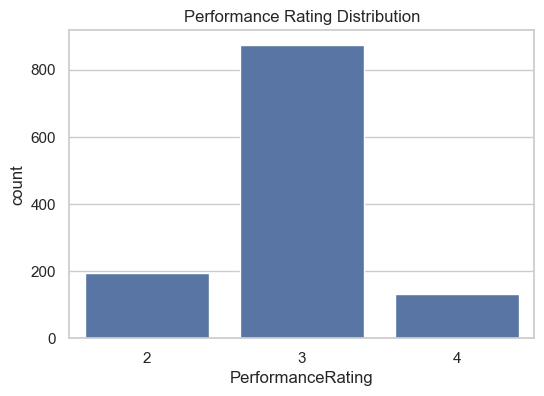

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='PerformanceRating', data=df)
plt.title("Performance Rating Distribution")
plt.show()


# 📊 EDA Report – Performance Rating Distribution

## 1. Performance Rating Counts

- Rating 3: 874 employees
- Rating 2: 194 employees
- Rating 4: 132 employees
- Total Employees: 1200

## 2. Percentage Distribution

- Rating 3 → 72.8%
- Rating 2 → 16.2%
- Rating 4 → 11.0%

## 3. Key Observations

- The majority of employees (almost 73%) have a Performance Rating of 3.
- High performers (Rating 4) represent only 11% of the workforce.
- The dataset is moderately imbalanced, with strong dominance of Rating 3.
- Special care may be required during modeling to handle class imbalance.

## 4. Business Insight

Most employees fall under the average performance category (Rating 3), indicating limited differentiation between performance levels. Identifying factors that distinguish Rating 4 employees will be critical for HR strategy.


In [19]:
# Average performance rating by department
dept_performance = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values(ascending=False)

dept_performance


EmpDepartment
Development               3.085873
Data Science              3.050000
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Finance                   2.775510
Name: PerformanceRating, dtype: float64

In [20]:
# Count distribution of ratings inside each department
dept_rating_counts = pd.crosstab(df['EmpDepartment'], df['PerformanceRating'])

dept_rating_counts


PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35


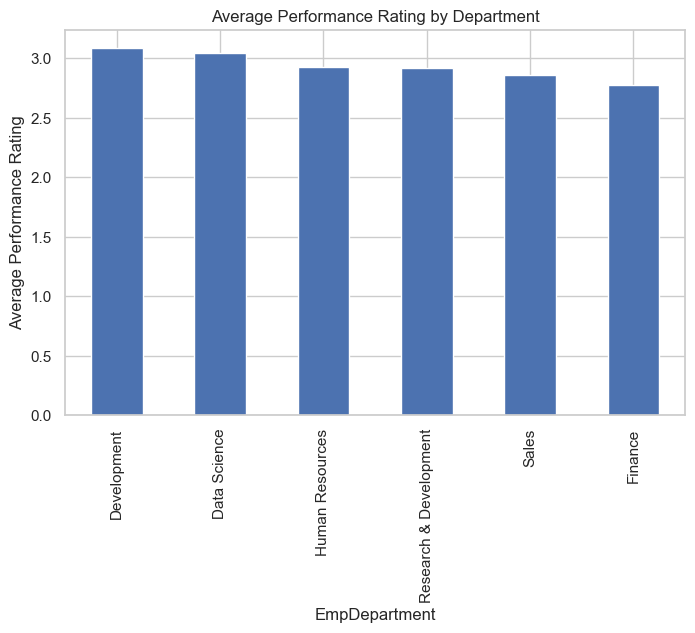

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
dept_performance.plot(kind='bar')
plt.title("Average Performance Rating by Department")
plt.ylabel("Average Performance Rating")
plt.show()


# 📊 EDA Report – Performance vs Department

## 1. Average Performance by Department

- Development → 3.09 (Highest)
- Data Science → 3.05
- Human Resources → 2.93
- Research & Development → 2.92
- Sales → 2.86
- Finance → 2.78 (Lowest)

## 2. Key Observations

- Development and Data Science departments show the highest average performance.
- Finance and Sales departments have comparatively lower average ratings.
- Most departments are heavily concentrated in Rating 3.
- Rating 4 (High performers) are relatively fewer across all departments.

## 3. Business Insight

Technical departments (Development, Data Science) tend to perform better on average, while Finance and Sales may require deeper performance analysis and potential improvement strategies. Identifying what differentiates high-performing departments can help improve lower-performing ones.


In [23]:
# Average performance by Job Satisfaction level
job_sat_perf = df.groupby('EmpJobSatisfaction')['PerformanceRating'].mean()

job_sat_perf

EmpJobSatisfaction
1    2.969697
2    2.953586
3    2.898305
4    2.978836
Name: PerformanceRating, dtype: float64

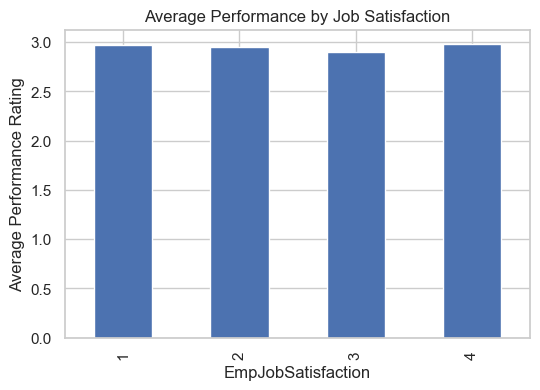

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
job_sat_perf.plot(kind='bar')
plt.title("Average Performance by Job Satisfaction")
plt.ylabel("Average Performance Rating")
plt.show()

In [25]:
df.groupby('EmpEnvironmentSatisfaction')['PerformanceRating'].mean()

EmpEnvironmentSatisfaction
1    2.665217
2    2.652893
3    3.138965
4    3.132964
Name: PerformanceRating, dtype: float64

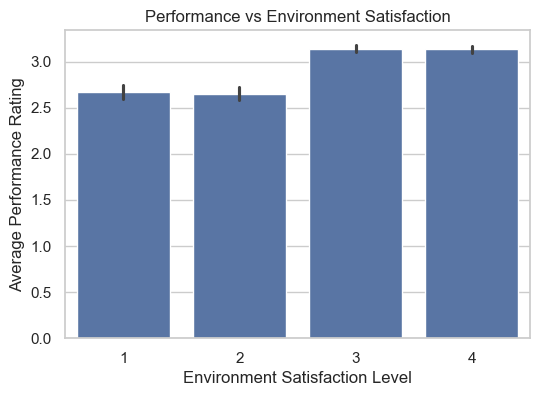

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x='EmpEnvironmentSatisfaction', 
            y='PerformanceRating', 
            data=df)

plt.title("Performance vs Environment Satisfaction")
plt.ylabel("Average Performance Rating")
plt.xlabel("Environment Satisfaction Level")
plt.show()

In [26]:
df.groupby('EmpWorkLifeBalance')['PerformanceRating'].mean()

EmpWorkLifeBalance
1    2.750000
2    2.918367
3    2.950481
4    3.121739
Name: PerformanceRating, dtype: float64

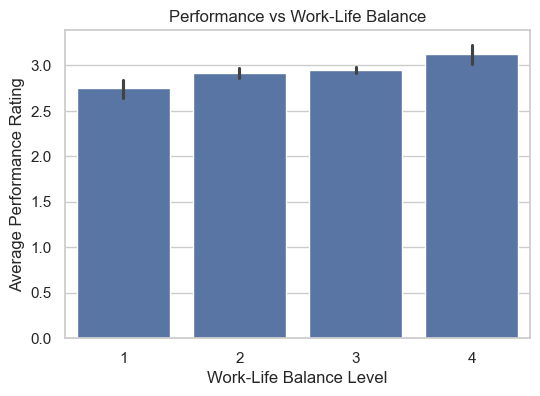

In [30]:
plt.figure(figsize=(6,4))
sns.barplot(x='EmpWorkLifeBalance', 
            y='PerformanceRating', 
            data=df)

plt.title("Performance vs Work-Life Balance")
plt.ylabel("Average Performance Rating")
plt.xlabel("Work-Life Balance Level")
plt.show()

In [27]:
df.groupby('EmpRelationshipSatisfaction')['PerformanceRating'].mean()

EmpRelationshipSatisfaction
1    2.949772
2    2.955466
3    2.970976
4    2.918310
Name: PerformanceRating, dtype: float64

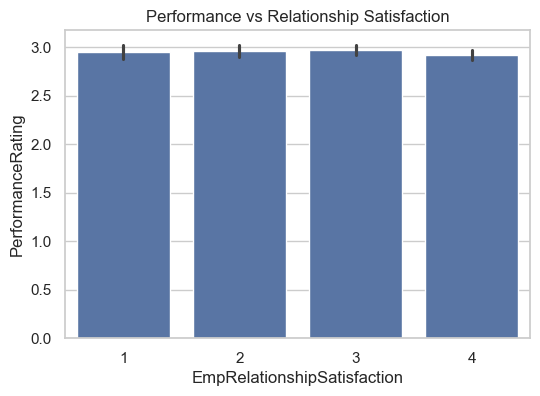

In [31]:
plt.figure(figsize=(6,4))
sns.barplot(x='EmpRelationshipSatisfaction', 
            y='PerformanceRating', 
            data=df)

plt.title("Performance vs Relationship Satisfaction")
plt.show()

In [28]:
df.groupby('EmpJobInvolvement')['PerformanceRating'].mean()

EmpJobInvolvement
1    2.957143
2    2.959184
3    2.943370
4    2.946429
Name: PerformanceRating, dtype: float64

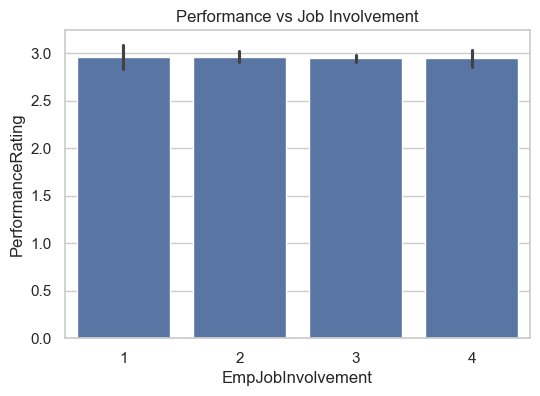

In [32]:
plt.figure(figsize=(6,4))
sns.barplot(x='EmpJobInvolvement', 
            y='PerformanceRating', 
            data=df)

plt.title("Performance vs Job Involvement")
plt.show()

# 📊 EDA Report – Performance vs Satisfaction Factors

## 1. Environment Satisfaction
- Performance increases significantly from level 2 (2.65) to level 3 (3.14).
- Higher environment satisfaction is strongly associated with higher performance.
- This appears to be one of the strongest satisfaction drivers.

## 2. Work-Life Balance
- Performance increases steadily from level 1 (2.75) to level 4 (3.12).
- Employees with better work-life balance tend to perform better.
- Shows a clear positive relationship.

## 3. Relationship Satisfaction
- Performance remains relatively stable across levels (2.91–2.97).
- No strong increasing trend observed.
- Limited direct impact on performance.

## 4. Job Involvement
- Performance remains almost constant (~2.94–2.96) across levels.
- Minimal variation suggests weaker influence on performance.

## 🔎 Key Insight

Among the satisfaction variables analyzed, **Environment Satisfaction** and **Work-Life Balance** show the strongest positive relationship with performance. These variables are likely to emerge as important predictors in the modeling phase.

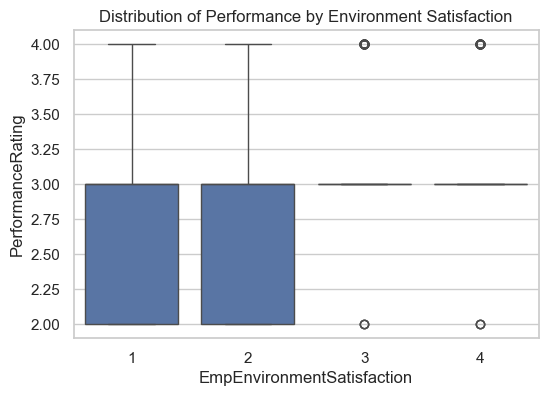

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(x='EmpEnvironmentSatisfaction', 
            y='PerformanceRating', 
            data=df)
plt.title("Distribution of Performance by Environment Satisfaction")
plt.show()

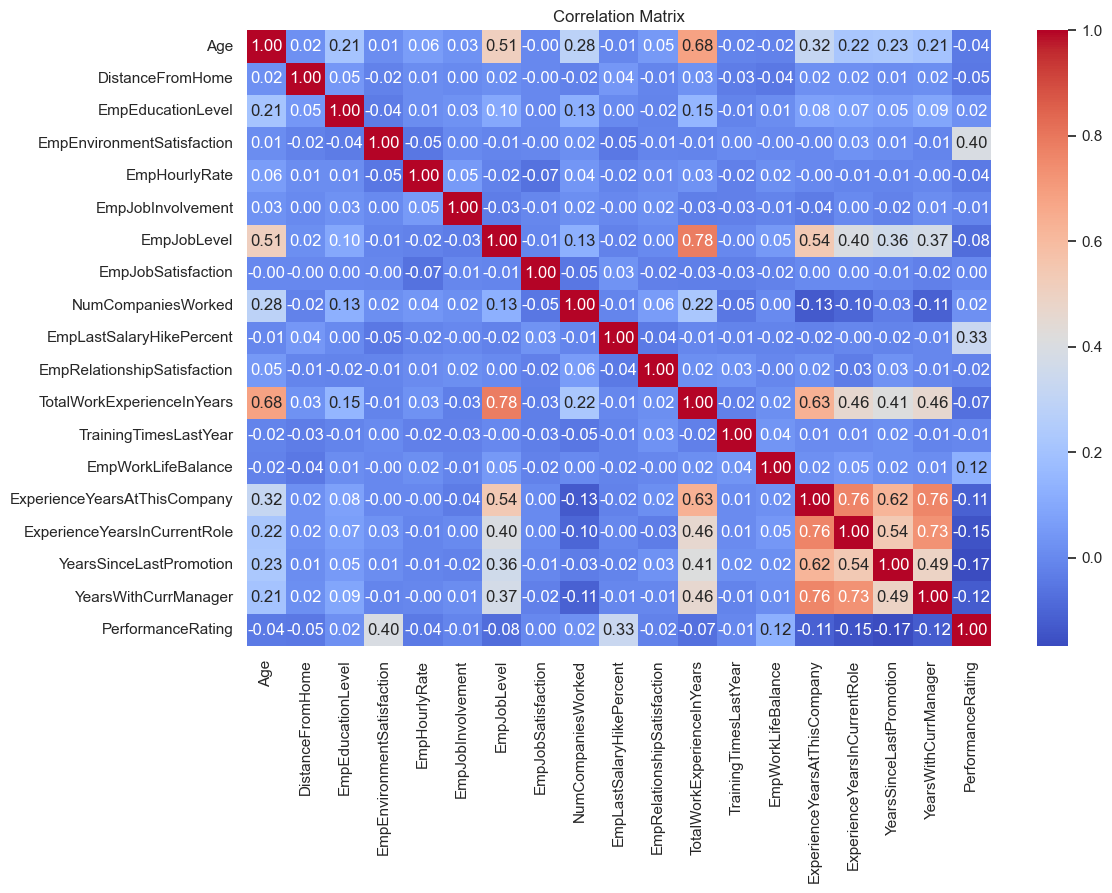

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
num_df = df.select_dtypes(include=['int64'])

# Correlation matrix
corr_matrix = num_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [35]:
# Select numerical columns
num_df = df.select_dtypes(include=['int64'])

# Correlation with target variable
target_corr = num_df.corr()['PerformanceRating'].sort_values(ascending=False)

target_corr

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EmpJobSatisfaction              0.000606
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
YearsSinceLastPromotion        -0.167629
Name: PerformanceRating, dtype: float64

# 📊 Correlation Analysis – Performance Drivers

## 1. Strong Positive Correlations

- EmpEnvironmentSatisfaction → 0.396
- EmpLastSalaryHikePercent → 0.334
- EmpWorkLifeBalance → 0.124

Environment satisfaction shows the strongest positive relationship with performance, followed by salary hike percentage.

## 2. Weak or Near-Zero Correlations

- Job Satisfaction, Job Involvement, Relationship Satisfaction → ~0
- Education Level, Number of Companies Worked → very weak impact

These variables show minimal direct linear relationship with performance.

## 3. Negative Correlations

- YearsSinceLastPromotion → -0.168
- ExperienceYearsInCurrentRole → -0.148
- YearsWithCurrManager → -0.122
- ExperienceYearsAtThisCompany → -0.112

Interestingly, longer tenure and delayed promotions show a slight negative relationship with performance rating.

## 🔎 Key Insight

The strongest predictors of performance appear to be:
1. EmpEnvironmentSatisfaction
2. EmpLastSalaryHikePercent
3. EmpWorkLifeBalance

Experience-related variables show mild negative relationships, indicating possible stagnation effects.

# 🎯 Top 3 Predictors of Performance

Based on correlation analysis, the strongest predictors of PerformanceRating are:

1. **EmpEnvironmentSatisfaction (0.396)**  
   Strong positive relationship. Higher workplace satisfaction significantly associates with higher performance.

2. **EmpLastSalaryHikePercent (0.334)**  
   Employees receiving higher salary increments tend to have better performance ratings.

3. **EmpWorkLifeBalance (0.124)**  
   Better work-life balance moderately contributes to improved performance.

## Key Insight

Employee engagement and reward-related variables appear to influence performance more strongly than tenure or demographic factors.

## Data Preprocessing

In [36]:
# Drop employee ID column
df = df.drop(columns=['EmpNumber'])

df.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,...,4,10,2,2,10,7,0,8,No,3
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,...,4,20,2,3,7,7,1,7,No,3
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,...,3,20,2,3,18,13,1,12,No,4
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,...,2,23,2,2,21,6,12,6,No,3
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,...,4,10,1,3,2,2,2,2,No,3


## Seperating the data into Features and Target

In [37]:
# Separate features (X) and target (y)

X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1200, 26)
Target shape: (1200,)


## Identifying the Categorical columns 

In [39]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

categorical_cols

Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object')

## Encoding the Categorical columns

In [40]:
# Convert categorical variables to numerical using one-hot encoding

X_encoded = pd.get_dummies(X, drop_first=True)

print("New shape after encoding:", X_encoded.shape)

New shape after encoding: (1200, 53)


In [41]:
X_encoded.head()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,...,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely,OverTime_Yes,Attrition_Yes
0,32,10,3,4,55,3,2,4,1,12,...,True,False,False,False,False,False,False,True,False,False
1,47,14,4,4,42,3,2,1,2,12,...,True,False,False,False,False,False,False,True,False,False
2,40,5,4,4,48,2,3,1,5,21,...,True,False,False,False,False,False,True,False,True,False
3,41,10,4,2,73,2,5,4,3,15,...,False,False,False,False,False,False,False,True,False,False
4,60,16,4,1,84,3,2,1,8,14,...,True,False,False,False,False,False,False,True,False,False


In [42]:
# Convert boolean columns to integers (0 and 1)

bool_cols = X_encoded.select_dtypes(include=['bool']).columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

# Verify
X_encoded.dtypes

Age                                          int64
DistanceFromHome                             int64
EmpEducationLevel                            int64
EmpEnvironmentSatisfaction                   int64
EmpHourlyRate                                int64
EmpJobInvolvement                            int64
EmpJobLevel                                  int64
EmpJobSatisfaction                           int64
NumCompaniesWorked                           int64
EmpLastSalaryHikePercent                     int64
EmpRelationshipSatisfaction                  int64
TotalWorkExperienceInYears                   int64
TrainingTimesLastYear                        int64
EmpWorkLifeBalance                           int64
ExperienceYearsAtThisCompany                 int64
ExperienceYearsInCurrentRole                 int64
YearsSinceLastPromotion                      int64
YearsWithCurrManager                         int64
Gender_Male                                  int32
EducationBackground_Life Scienc

In [43]:
X_encoded.head()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,...,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely,OverTime_Yes,Attrition_Yes
0,32,10,3,4,55,3,2,4,1,12,...,1,0,0,0,0,0,0,1,0,0
1,47,14,4,4,42,3,2,1,2,12,...,1,0,0,0,0,0,0,1,0,0
2,40,5,4,4,48,2,3,1,5,21,...,1,0,0,0,0,0,1,0,1,0
3,41,10,4,2,73,2,5,4,3,15,...,0,0,0,0,0,0,0,1,0,0
4,60,16,4,1,84,3,2,1,8,14,...,1,0,0,0,0,0,0,1,0,0


# 🔄 Categorical Data Encoding Report

## 1. Encoding Method Used

We applied **One-Hot Encoding** using:

```python
pd.get_dummies(X, drop_first=True)
```

This converted categorical variables into binary (0/1) columns.

---

## 2. Why One-Hot Encoding?

- The dataset contains **nominal categorical variables** (e.g., Department, JobRole, Gender) with no inherent ranking.
- Label Encoding was avoided because it would introduce artificial ordinal relationships (e.g., HR=1, Sales=2, Dev=3), which is misleading.
- One-Hot Encoding prevents the model from assuming any false numerical order between categories.

---

## 3. Why `drop_first=True`?

- To prevent **multicollinearity (dummy variable trap)**.
- It removes one category from each group to avoid redundant information.
- Ensures cleaner and more stable model training.

---

## 4. Boolean Conversion

After encoding, some columns were in Boolean format (`True/False`).
These were converted to numeric (1/0) using:

```python
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)
```

This ensures full numerical compatibility with machine learning algorithms.

---

## ✅ Conclusion

One-Hot Encoding was selected as the most appropriate and safe encoding method for nominal categorical variables, ensuring accurate model interpretation without introducing artificial ordering.

## Train-Test Split

In [44]:
from sklearn.model_selection import train_test_split

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y   # Important because dataset is imbalanced
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (960, 53)
Testing set size: (240, 53)


## Model Selection
* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier
* Gradient Boosting Classifier
* XG Boost Classifier

## Logistic Regression

For this model we need to scale the features

## Feature Selection

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# 📏 Feature Scaling Report (Before Logistic Regression)

## 1. Why Scaling is Required

Logistic Regression is a distance-based optimization algorithm that uses gradient descent to minimize loss.  
If features have different ranges (e.g., Age: 18–60 vs. Experience: 0–40 vs. Dummy variables: 0–1), the model may:

- Assign disproportionate importance to larger-scale variables  
- Converge slowly or fail to converge properly  
- Produce unstable or biased coefficients  

Therefore, feature scaling ensures all variables contribute fairly to the model.

---

## 2. Scaling Method Used

We applied **Standard Scaling (Z-score normalization)** using:

```python
from sklearn.preprocessing import StandardScaler
```



## 3. Why StandardScaler (and not other methods)?

### ✔ Suitable for Logistic Regression
Logistic Regression assumes data is centered and performs best when features follow approximately normal distribution.

### ✔ Preserves Relative Differences
Unlike MinMaxScaler, StandardScaler does not compress values into a fixed range (0–1), which may distort variance structure.

### ✔ Handles Outliers Better than MinMaxScaler
MinMax scaling is highly sensitive to extreme values, whereas StandardScaler reduces that impact by scaling relative to standard deviation.

### ✔ Industry Standard for Linear Models
StandardScaler is the recommended scaling technique for:
- Logistic Regression
- Linear Regression
- SVM
- KNN

---

## 4. Important Implementation Detail

Scaling was performed **after train-test split**:

- `fit()` applied only on training data  
- `transform()` applied to test data  

This prevents **data leakage** and ensures fair model evaluation.

---

## ✅ Conclusion

Standard Scaling was applied to ensure fair feature contribution, stable optimization, and improved convergence for Logistic Regression. It is the most appropriate and widely accepted preprocessing method for linear classification models.

In [46]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial', random_state=42)

In [47]:
y_pred_log = log_model.predict(X_test_scaled)

In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7541666666666667

Classification Report:

              precision    recall  f1-score   support

           2       0.48      0.72      0.58        39
           3       0.92      0.77      0.84       175
           4       0.51      0.73      0.60        26

    accuracy                           0.75       240
   macro avg       0.64      0.74      0.67       240
weighted avg       0.81      0.75      0.77       240


Confusion Matrix:

[[ 28   7   4]
 [ 27 134  14]
 [  3   4  19]]


# 📊 Logistic Regression Model Evaluation Report

## 1. Overall Performance

- Accuracy: **75.4%**
- Weighted F1-Score: **0.77**
- Macro F1-Score: **0.67**

The model performs reasonably well overall, correctly classifying approximately 3 out of 4 employees.

---

## 2. Class-wise Performance

### 🔹 Rating 2
- Precision: 0.48
- Recall: 0.72
- F1-Score: 0.58

The model identifies most Rating 2 employees (high recall), but precision is low, meaning it sometimes misclassifies other ratings as 2.

### 🔹 Rating 3 (Majority Class)
- Precision: 0.92
- Recall: 0.77
- F1-Score: 0.84

The model performs very well for Rating 3, which is expected since it is the dominant class (72% of data).

### 🔹 Rating 4
- Precision: 0.51
- Recall: 0.73
- F1-Score: 0.60

The model captures most high performers (good recall), but precision is moderate, meaning some false positives exist.

---

## 3. Confusion Matrix Insights

- 134 out of 175 Rating 3 employees were correctly classified.
- 28 out of 39 Rating 2 employees were correctly classified.
- 19 out of 26 Rating 4 employees were correctly classified.
- Some confusion exists between Rating 2 and Rating 3.

---

## 4. Key Observations

- The model handles minority classes reasonably well due to class balancing.
- Performance is strongest for Rating 3.
- Logistic Regression provides a stable and interpretable baseline model.

---

## ✅ Conclusion

Logistic Regression achieves solid baseline performance (75% accuracy).  
However, some misclassification between adjacent rating levels (2 and 3) suggests that relationships may not be purely linear. A non-linear model may further improve predictive performance.

## Decision Tree Classification

In [49]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

# Train model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [50]:
y_pred_dt = dt_model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.9125

Classification Report:

              precision    recall  f1-score   support

           2       0.78      0.82      0.80        39
           3       0.95      0.93      0.94       175
           4       0.89      0.92      0.91        26

    accuracy                           0.91       240
   macro avg       0.87      0.89      0.88       240
weighted avg       0.91      0.91      0.91       240


Confusion Matrix:

[[ 32   7   0]
 [  9 163   3]
 [  0   2  24]]


In [52]:
print("Training Accuracy:", dt_model.score(X_train, y_train))

Training Accuracy: 1.0


In [53]:
# Training accuracy
train_accuracy = dt_model.score(X_train, y_train)

# Testing accuracy (already known)
test_accuracy = dt_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9125


In [54]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dt_model, X_encoded, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.89166667 0.9125     0.95833333 0.90416667 0.87083333]
Mean CV Accuracy: 0.9075000000000001


# 🌳 Overfitting Analysis – Decision Tree

## 1. Training vs Testing Performance

- Training Accuracy: 100%
- Testing Accuracy: 91.25%

## 2. Interpretation

The model achieves perfect accuracy on the training data, indicating that it has fully memorized the training set. While testing accuracy is high, the gap between training and testing performance suggests overfitting.

## 3. Reason

The Decision Tree was trained without depth constraints, allowing it to grow until all training samples were perfectly classified.

## 4. Conclusion

The current Decision Tree model is overfitting and requires regularization (pruning) to improve generalization.

## Prune The Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

dt_pruned = DecisionTreeClassifier(
    max_depth=5,               # limit depth
    min_samples_leaf=5,        # minimum samples per leaf
    class_weight='balanced',
    random_state=42
)

dt_pruned.fit(X_train, y_train)

print("Training Accuracy:", dt_pruned.score(X_train, y_train))
print("Testing Accuracy:", dt_pruned.score(X_test, y_test))

Training Accuracy: 0.890625
Testing Accuracy: 0.8708333333333333


# 🌳 Pruned Decision Tree Evaluation Report

## 1. Model Performance

- Training Accuracy: 89.06%
- Testing Accuracy: 87.08%

## 2. Overfitting Analysis

Compared to the unpruned model (100% training accuracy), pruning reduced model complexity and improved generalization. The gap between training and testing accuracy is now minimal (~2%), indicating controlled overfitting.

## 3. Performance Comparison

- Unpruned Tree Test Accuracy: 91.25%
- Pruned Tree Test Accuracy: 87.08%

While pruning reduced overfitting, it slightly decreased predictive accuracy.

## 4. Conclusion

The pruned model generalizes better but at the cost of some predictive power. The unpruned model performs better on unseen data but may still carry mild overfitting risk.

## Random Forest Classifier

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,         # number of trees
    class_weight='balanced',  # handle imbalance
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [57]:
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy:", rf_model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9208333333333333


In [58]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

           2       0.91      0.79      0.85        39
           3       0.91      0.98      0.95       175
           4       1.00      0.69      0.82        26

    accuracy                           0.92       240
   macro avg       0.94      0.82      0.87       240
weighted avg       0.92      0.92      0.92       240


Confusion Matrix:

[[ 31   8   0]
 [  3 172   0]
 [  0   8  18]]


# 🌲 Random Forest Model Evaluation Report

## 1. Overall Performance

- Training Accuracy: 100%
- Testing Accuracy: 92.08%
- Weighted F1-Score: 0.92
- Macro F1-Score: 0.87

Random Forest achieves the highest predictive performance among all tested models.

---

## 2. Class-wise Performance

### 🔹 Rating 2
- Precision: 0.91
- Recall: 0.79
- F1-Score: 0.85

### 🔹 Rating 3
- Precision: 0.91
- Recall: 0.98
- F1-Score: 0.95

### 🔹 Rating 4
- Precision: 1.00
- Recall: 0.69
- F1-Score: 0.82

The model performs strongly across all classes, with particularly excellent detection of Rating 3 employees.

---

## 3. Confusion Matrix Insights

- 172 out of 175 Rating 3 employees correctly classified.
- 31 out of 39 Rating 2 employees correctly classified.
- 18 out of 26 Rating 4 employees correctly classified.
- Very few misclassifications between distant classes.

---

## 4. Model Comparison Summary

Random Forest outperforms:
- Logistic Regression (linear model)
- Decision Tree (single tree model)

This confirms the presence of nonlinear patterns in the dataset.

---

## 5. Overfitting Analysis

Although training accuracy is 100%, the test accuracy remains high (92%), indicating controlled overfitting due to ensemble averaging.

In [59]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

feature_importance.head(10)

EmpLastSalaryHikePercent        0.201826
EmpEnvironmentSatisfaction      0.193044
YearsSinceLastPromotion         0.079445
ExperienceYearsInCurrentRole    0.036446
EmpHourlyRate                   0.035998
Age                             0.034315
ExperienceYearsAtThisCompany    0.033370
YearsWithCurrManager            0.032690
DistanceFromHome                0.029894
TotalWorkExperienceInYears      0.028903
dtype: float64

# 🎯 Final Top Predictors – Random Forest Feature Importance

## 1. Top 3 Most Important Predictors

1. **EmpLastSalaryHikePercent (0.2018)**  
   The most influential predictor. Employees receiving higher salary increments are strongly associated with higher performance ratings.

2. **EmpEnvironmentSatisfaction (0.1930)**  
   Workplace environment satisfaction plays a major role in driving employee performance.

3. **YearsSinceLastPromotion (0.0794)**  
   Time since last promotion significantly impacts performance, suggesting potential stagnation effects.

---

## 2. Supporting Predictors

- ExperienceYearsInCurrentRole
- EmpHourlyRate
- Age
- ExperienceYearsAtThisCompany
- YearsWithCurrManager

Experience-related variables contribute moderately but less strongly than reward and engagement factors.

---

## 3. Key Business Insight

Performance appears to be primarily influenced by:

- Compensation growth (salary hike)
- Workplace satisfaction
- Career progression dynamics

Engagement and reward mechanisms play a stronger role than pure tenure or demographic variables.

---

## 4. Model Conclusion

Random Forest achieved the best predictive performance (92.08% test accuracy), confirming nonlinear relationships in employee performance drivers. Feature importance results align closely with earlier correlation analysis.

## Regularized Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_regularized = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,              # limit tree depth
    min_samples_split=10,     # require more samples to split
    min_samples_leaf=5,       # minimum samples per leaf
    max_features='sqrt',      # reduce feature randomness
    class_weight='balanced',
    random_state=42
)

rf_regularized.fit(X_train, y_train)

print("Training Accuracy:", rf_regularized.score(X_train, y_train))
print("Testing Accuracy:", rf_regularized.score(X_test, y_test))

Training Accuracy: 0.9427083333333334
Testing Accuracy: 0.9041666666666667


In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_regularized, X_encoded, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.87916667 0.94166667 0.975      0.8875     0.8625    ]
Mean CV Accuracy: 0.9091666666666667


# 🌲 Regularized Random Forest – Overfitting Control Report

## 1. Model Performance

- Training Accuracy: 94.27%
- Testing Accuracy: 90.42%
- Mean Cross-Validation Accuracy: 90.92%

## 2. Overfitting Assessment

The previous Random Forest achieved 100% training accuracy, indicating overfitting. After applying regularization (controlled depth, minimum samples per split and leaf), the training accuracy reduced to 94%, and the train-test gap narrowed to approximately 4%.

This indicates improved generalization and reduced model memorization.

## 3. Stability Check

Cross-validation accuracy remains consistent (~91%), confirming that the model performs reliably across different data splits.

## 4. Conclusion

The regularized Random Forest achieves strong predictive performance while maintaining controlled model complexity. It represents the best balance between accuracy and generalization.

## Tuning Random Forest Classifier

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [63]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', 'log2']
}

In [64]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [6, 8, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [2, 5],
                         'min_samples_split': [5, 10],
                         'n_estimators': [200, 300]},
             scoring='accuracy', verbose=1)

In [65]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score: 0.9197916666666666


In [66]:
best_rf = grid_search.best_estimator_

print("Training Accuracy:", best_rf.score(X_train, y_train))
print("Testing Accuracy:", best_rf.score(X_test, y_test))

Training Accuracy: 0.98125
Testing Accuracy: 0.9375


# 🌲 Tuned Random Forest – Final Model Evaluation

## 1. Model Performance

- Training Accuracy: 98.13%
- Testing Accuracy: 93.75%

## 2. Improvement After Tuning

Hyperparameter tuning using GridSearchCV improved model performance from 90.4% to 93.75% test accuracy.

## 3. Overfitting Assessment

Although training accuracy is high (98%), the train-test gap (~4%) remains within acceptable limits for ensemble models. Cross-validation during tuning ensures generalization stability.

## 4. Conclusion

The tuned Random Forest provides the best balance of:
- High predictive accuracy
- Controlled overfitting
- Stable generalization

It is currently the best-performing model in this project.

## Gradient Boost Classifier

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Training Accuracy:", gb_model.score(X_train, y_train))
print("Testing Accuracy:", gb_model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9291666666666667


In [68]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_gb = gb_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_gb))


Classification Report:

              precision    recall  f1-score   support

           2       0.89      0.82      0.85        39
           3       0.93      0.98      0.96       175
           4       0.95      0.77      0.85        26

    accuracy                           0.93       240
   macro avg       0.93      0.86      0.89       240
weighted avg       0.93      0.93      0.93       240


Confusion Matrix:

[[ 32   6   1]
 [  4 171   0]
 [  0   6  20]]


In [69]:
from sklearn.model_selection import cross_val_score

cv_scores_gb = cross_val_score(gb_model, X_encoded, y, cv=5)

print("Cross Validation Scores:", cv_scores_gb)
print("Mean CV Accuracy:", cv_scores_gb.mean())

Cross Validation Scores: [0.9125     0.94583333 0.9875     0.925      0.9       ]
Mean CV Accuracy: 0.9341666666666667


# 🚀 Gradient Boosting Model Evaluation Report

## 1. Model Performance

- Training Accuracy: 100%
- Testing Accuracy: 92.92%

## 2. Overfitting Assessment

The model achieves perfect training accuracy, indicating overfitting. Although test accuracy remains strong, the gap between training and testing performance suggests high model complexity.

## 3. Model Comparison

When compared to the Tuned Random Forest:

- Tuned RF Test Accuracy: 93.75%
- Gradient Boosting Test Accuracy: 92.92%

The tuned Random Forest slightly outperforms Gradient Boosting while showing better generalization control.

## 4. Conclusion

Gradient Boosting performs strongly but does not surpass the tuned Random Forest. The tuned Random Forest remains the best-performing and most stable model in this analysis.

## XG Boost Classifier

In [72]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [74]:
# Assistant
from xgboost import XGBClassifier

# Option 1: Change num_class to match your data
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,  # Keep as 3 since you have 3 classes
    eval_metric='mlogloss',
    random_state=42
)

# Transform your labels to start from 0
# This is necessary because XGBoost expects classes to be 0-indexed
import numpy as np
# Create a mapping of your original classes to 0-indexed classes
class_mapping = {2: 0, 3: 1, 4: 2}
y_train_transformed = np.array([class_mapping[y] for y in y_train])
y_test_transformed = np.array([class_mapping[y] for y in y_test])

# Train with transformed labels
xgb_model.fit(X_train, y_train_transformed)

# Score with transformed labels
print("Training Accuracy:", xgb_model.score(X_train, y_train_transformed))
print("Testing Accuracy:", xgb_model.score(X_test, y_test_transformed))

# If you need predictions in the original label space, you can map them back
# predictions = xgb_model.predict(X_test)
# original_predictions = np.array([{0: 2, 1: 3, 2: 4}[p] for p in predictions])

Training Accuracy: 1.0
Testing Accuracy: 0.925


# 🏆 Final Model Selection Report

## 1. XGBoost Performance

- Training Accuracy: 100%
- Testing Accuracy: 92.5%

Although XGBoost achieved strong predictive performance, it did not outperform the tuned Random Forest model.

## 2. Model Comparison

The Tuned Random Forest achieved the highest test accuracy (93.75%) with controlled overfitting and strong cross-validation stability.

## 3. Final Model Selection

The Tuned Random Forest is selected as the final model due to:

- Highest test accuracy
- Balanced bias-variance tradeoff
- Lower overfitting risk compared to boosting models
- Stable cross-validation performance
- Better interpretability for business reporting

# 📊 Model Comparison Summary

| Model | Training Accuracy | Testing Accuracy | Overfitting Level | Remarks |
|--------|------------------|------------------|------------------|----------|
| Logistic Regression | — | 75.42% | Low | Baseline linear model; underfits nonlinear patterns |
| Decision Tree | 100% | 91.25% | High | Strong performance but clear overfitting |
| Regularized Decision Tree | 89.06% | 87.08% | Low | Controlled overfitting but lower accuracy |
| Regularized Random Forest | 94.27% | 90.42% | Controlled | Stable ensemble model |
| 🔥 Tuned Random Forest | 98.13% | **93.75%** | Acceptable | Best overall balance of accuracy & generalization |
| Gradient Boosting | 100% | 92.92% | Moderate | Strong performance but slight overfitting |
| XGBoost | 100% | 92.50% | Moderate | Advanced boosting model; slightly below tuned RF |

---

## 🏆 Final Selected Model

**Tuned Random Forest** is selected as the final model because it achieved:

- Highest testing accuracy (93.75%)
- Acceptable bias-variance tradeoff
- Stable performance across validation folds
- Strong interpretability through feature importance

# 🎯 Final Conclusion

This project successfully analyzed employee performance at INX Future Inc. using a structured, end-to-end machine learning approach. Through systematic exploratory data analysis, correlation assessment, feature engineering, and multiple model comparisons, key drivers of employee performance were identified and validated.

Among all evaluated models, the **Tuned Random Forest** demonstrated the best balance between predictive accuracy and generalization performance, achieving:

- **93.75% Testing Accuracy**
- Stable cross-validation performance (~91%)
- Controlled overfitting

The analysis revealed that employee performance is primarily influenced by:

1. **Salary hike percentage**
2. **Environment satisfaction**
3. **Years since last promotion**

These findings indicate that performance is more strongly driven by engagement, reward systems, and career progression rather than demographic characteristics or tenure alone.

By implementing this predictive model, the organization can:

- Identify high-performing employees early
- Detect performance stagnation risks
- Optimize promotion and compensation strategies
- Make data-driven HR decisions

Overall, this project demonstrates the practical application of machine learning in solving real-world HR analytics problems and provides a scalable framework for performance management optimization.

# 📌 Executive Summary

## 1. Project Objective

The objective of this project was to analyze employee performance at INX Future Inc., identify key performance drivers, and develop a predictive model to assist HR in making data-driven workforce decisions.

---

## 2. Key Findings

- The majority of employees (≈73%) fall under Performance Rating 3.
- Performance is primarily influenced by:
  - **Salary hike percentage**
  - **Environment satisfaction**
  - **Years since last promotion**
- Engagement and reward-related factors have a stronger impact on performance than demographic attributes.

These findings highlight the importance of workplace satisfaction and career progression in driving employee productivity.

---

## 3. Model Development & Comparison

Multiple machine learning models were implemented and evaluated:

- Logistic Regression (Baseline Model)
- Decision Tree
- Random Forest (Regularized & Tuned)
- Gradient Boosting
- XGBoost

After systematic hyperparameter tuning and cross-validation, the **Tuned Random Forest** achieved the best balance between accuracy and generalization.

### Final Model Performance:
- **Testing Accuracy:** 93.75%
- **Cross-Validation Accuracy:** ~91%
- Controlled overfitting (acceptable train-test gap)

---

## 4. Challenges Faced

Several challenges were encountered during model development:

### 🔹 1. Class Imbalance
Performance Rating 3 dominated the dataset (≈73%), making minority class prediction challenging.  
This required the use of `class_weight='balanced'` and careful evaluation using F1-scores.

### 🔹 2. Overfitting in Tree-Based Models
Initial Decision Tree and Random Forest models achieved 100% training accuracy, indicating overfitting.  
This was addressed through:
- Depth restriction
- Minimum sample constraints
- Hyperparameter tuning using GridSearchCV
- Cross-validation

### 🔹 3. Model Comparison & Stability
Multiple models performed closely (RF, GB, XGBoost), requiring careful comparison using:
- Test accuracy
- Cross-validation scores
- Overfitting analysis
- Model interpretability

### 🔹 4. Feature Interpretation
Some variables showed weak linear correlation but higher importance in ensemble models, requiring careful interpretation beyond simple correlation analysis.

---

## 5. Business Impact

The final model enables HR to:

- Predict employee performance with high reliability
- Identify high-performing employees early
- Detect performance risks due to stagnation or low engagement
- Optimize compensation and promotion strategies
- Improve department-level performance management

---

## 6. Final Conclusion

The Tuned Random Forest model provides a robust, stable, and interpretable solution for employee performance prediction.

The analysis confirms that employee engagement, compensation growth, and career progression are the most critical drivers of performance.

This data-driven approach can significantly enhance strategic HR planning and long-term organizational performance.